In [11]:
import pandas as pd
import numpy as np
import re

In [12]:
problem_df = pd.read_csv("reddit_startup_ideas_dataset.csv")
solution_df = pd.read_csv("reddit_master_dataset.csv")

print("Problem dataset size:", len(problem_df))
print("Solution dataset size:", len(solution_df))

Problem dataset size: 20054
Solution dataset size: 24194


In [13]:
problem_df["dataset_type"] = "problem"
solution_df["dataset_type"] = "solution"

In [14]:
df = pd.concat([problem_df, solution_df], ignore_index=True)

print("Combined dataset size:", len(df))

Combined dataset size: 44248


In [15]:
df = df.drop_duplicates(subset=["title","url"])

print("Dataset size after removing duplicates:", len(df))

Dataset size after removing duplicates: 44248


In [16]:
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
df["content"] = df["content"].str.lower()

df[["title","content"]].head()

,title,content
0,What was your experience using a Ouija board?,what was your experience using a ouija board?
1,What is a poor man's luxury that you refuse to...,what is a poor man's luxury that you refuse to...
2,What’s a moment at work that made you realize ...,what’s a moment at work that made you realize ...
3,What is the most money you’ve made from tradin...,what is the most money you’ve made from tradin...
4,What's a time you felt truly trapped ?,what's a time you felt truly trapped ?


In [17]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["content_clean"] = df["content"].apply(clean_text)

df["content_clean"].head()

0        what was your experience using a ouija board 
1    what is a poor mans luxury that you refuse to ...
2    whats a moment at work that made you realize t...
3    what is the most money youve made from trading...
4                whats a time you felt truly trapped  
Name: content_clean, dtype: object

In [18]:
df.to_csv("startup_opportunity_dataset.csv", index=False)

print("Dataset saved successfully")
print("Final dataset size:", len(df))

Dataset saved successfully
Final dataset size: 44248


In [24]:
problem_patterns = [

# direct problems
"problem",
"issue",
"struggling",
"frustrating",
"annoying",
"hate when",
"pain to",
"too difficult",
"too expensive",
"doesn't work",
"does not work",

# missing solutions
"wish there was",
"why isn't there",
"why is there no",
"there should be",
"no good way",
"can't find",

# searching for tools
"looking for",
"need a tool",
"need an app",
"need software",
"any tool",
"any software",
"any app",
"tool for",
"software for",
"app for",

# recommendation signals
"any recommendations",
"what do you use",
"what tool do you use",
"what software do you use",
"what app do you use",

# comparisons
"better than",
"alternative to",
"competitor to",
"replacement for",

# workflow inefficiencies
"manual process",
"using spreadsheets",
"doing this manually",
"takes too long",
"time consuming",

# improvement signals
"missing feature",
"needs improvement",
"feature request",
"should have",
"would be great if"
]


question_signals = [
"how do you",
"how do people",
"how can i",
"how are you",
"how to",
"what is the best",
"what's the best",
"is there a tool",
"is there an app",
"is there software",
"any good tool",
"any good app",
"any good software"
]


def detect_problem(text):

    if not isinstance(text, str):
        return 0

    text = text.lower()

    for p in problem_patterns:
        if p in text:
            return 1

    for q in question_signals:
        if q in text:
            return 1

    return 0


df["problem_signal"] = df["content_clean"].apply(detect_problem)

print("Problem posts detected:", df["problem_signal"].sum())

Problem posts detected: 11554


In [25]:
problem_posts = df[df["problem_signal"] == 1]

print("Number of problem posts:", len(problem_posts))
problem_posts[["title","subreddit","score"]].head(10)

Number of problem posts: 11554


,title,subreddit,score
7,For conspiracy theorists from before the past ...,AskReddit,1.0
16,How do you know when you're falling out of love?,AskReddit,2.0
18,How do you replay classic PlayStation games li...,AskReddit,2.0
22,"Reddit, how do you discard the supposed love o...",AskReddit,1.0
50,What is the best question from ask reddit you ...,AskReddit,1.0
57,How do you manage your anxiety?,AskReddit,0.0
66,How do you become irresistible to a man ?,AskReddit,1.0
67,"If the world’s richest billionaires (Musk, Bez...",AskReddit,0.0
103,How do you get through your dissertation? How ...,AskReddit,1.0
109,How do you get sound on Reddit gifs on the app?,AskReddit,0.0


In [26]:
problem_posts.to_csv("problem_posts_dataset.csv", index=False)

print("Problem dataset saved")

Problem dataset saved


In [2]:


# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("startup_opportunity_dataset.csv")

print("Total posts:", len(df))
print("Unique subreddits:", df["subreddit"].nunique())

# ============================================
# CREATE TEXT COLUMN
# ============================================

df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

# ============================================
# CLEAN TEXT
# ============================================

df["content_clean"] = (
    df["content"]
    .str.lower()
    .str.replace(r"http\S+", "", regex=True)
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
)

# ============================================
# DEMAND / PROBLEM SIGNAL DETECTION
# ============================================

problem_patterns = [

"problem","issue","struggling","frustrating","annoying",
"hate when","pain to","too difficult","too expensive",

"looking for","need a tool","need an app","need software",
"any tool","any software","any app",

"any recommendations","what do you use","what software do you use",

"alternative to","better than","replacement for",

"manual process","using spreadsheets","doing this manually",

"missing feature","needs improvement","feature request",

"wish there was","why isnt there","why is there no"
]

question_signals = [

"how do you","how can i","how to",
"what is the best","whats the best",
"is there a tool","is there an app",
"any good tool","any good app"
]


def detect_problem(text):

    if not isinstance(text,str):
        return 0

    text = text.lower()

    for p in problem_patterns:
        if p in text:
            return 1

    for q in question_signals:
        if q in text:
            return 1

    return 0


df["problem_signal"] = df["content_clean"].apply(detect_problem)

problem_posts = df[df["problem_signal"] == 1]

print("Problem posts detected:", len(problem_posts))

# ============================================
# INSTALL LIBRARIES
# ============================================

%pip install sentence-transformers umap-learn hdbscan scikit-learn torch

# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

import umap
import hdbscan

from sklearn.feature_extraction.text import TfidfVectorizer

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("startup_opportunity_dataset.csv")

print("Total posts:", len(df))
print("Unique subreddits:", df["subreddit"].nunique())

# ============================================
# CREATE TEXT COLUMN
# ============================================

df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

# ============================================
# CLEAN TEXT
# ============================================

df["content_clean"] = (
    df["content"]
    .str.lower()
    .str.replace(r"http\S+", "", regex=True)
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
)

# ============================================
# PROBLEM SIGNAL DETECTION
# ============================================

problem_patterns = [

"problem","issue","struggling","frustrating","annoying",
"hate when","pain to","too difficult","too expensive",

"looking for","need a tool","need an app","need software",
"any tool","any software","any app",

"any recommendations","what do you use","what software do you use",

"alternative to","better than","replacement for",

"manual process","using spreadsheets","doing this manually",

"missing feature","needs improvement","feature request",

"wish there was","why isnt there","why is there no"
]

question_signals = [

"how do you","how can i","how to",
"what is the best","whats the best",
"is there a tool","is there an app",
"any good tool","any good app"
]


def detect_problem(text):

    if not isinstance(text,str):
        return 0

    text = text.lower()

    for p in problem_patterns:
        if p in text:
            return 1

    for q in question_signals:
        if q in text:
            return 1

    return 0


df["problem_signal"] = df["content_clean"].apply(detect_problem)

problem_posts = df[df["problem_signal"] == 1]

print("Problem posts detected:", len(problem_posts))

# ============================================
# KEEP TOP SIGNAL POSTS (SPEED + QUALITY)
# ============================================

problem_posts = problem_posts.sort_values(
    by=["score","comments"],
    ascending=False
).head(5000)

print("Posts used for clustering:", len(problem_posts))

# ============================================
# LOAD EMBEDDING MODEL
# ============================================

import torch
torch.set_num_threads(4)

print("\nLoading embedding model...")

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = problem_posts["content_clean"].tolist()

# ============================================
# GENERATE EMBEDDINGS
# ============================================

print("Generating embeddings...")



embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings generated:", len(embeddings))

# ============================================
# DIMENSION REDUCTION (UMAP)
# ============================================

print("\nRunning UMAP dimensionality reduction...")

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric='cosine',
    random_state=42
)

umap_embeddings = umap_model.fit_transform(embeddings)

# ============================================
# CLUSTERING (HDBSCAN)
# ============================================

print("\nRunning HDBSCAN clustering...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric='euclidean',
    cluster_selection_method='eom'
)

clusters = clusterer.fit_predict(umap_embeddings)

problem_posts["cluster"] = clusters

# ============================================
# REMOVE NOISE
# ============================================

problem_posts = problem_posts[problem_posts["cluster"] != -1]

print("Clusters detected:", problem_posts["cluster"].nunique())

# ============================================
# CLUSTER SIZE (MARKET DEMAND)
# ============================================

cluster_sizes = problem_posts["cluster"].value_counts()

print("\nMarket Demand (cluster size):")

print(cluster_sizes.head(10))

# ============================================
# KEYWORD EXTRACTION
# ============================================

print("\nExtracting cluster keywords...")

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

tfidf_matrix = vectorizer.fit_transform(problem_posts["content_clean"])

terms = vectorizer.get_feature_names_out()

for cluster_id in cluster_sizes.head(10).index:

    print("\n===============================")
    print("Opportunity Cluster:", cluster_id)
    print("===============================")

    cluster_texts = problem_posts[
        problem_posts["cluster"] == cluster_id
    ]["content_clean"]

    cluster_tfidf = vectorizer.transform(cluster_texts)

    mean_tfidf = cluster_tfidf.mean(axis=0)

    keywords = np.array(terms)[np.argsort(mean_tfidf.A1)[::-1][:10]]

    print("\nKey topics:", keywords)

    print("\nExample discussions:")

    sample_posts = problem_posts[
        problem_posts["cluster"] == cluster_id
    ]["title"].head(5)

    for post in sample_posts:
        print("-", post)

# ============================================
# SAVE RESULTS
# ============================================

problem_posts.to_csv("ai_detected_opportunities.csv", index=False)

print("\nSaved: ai_detected_opportunities.csv")

print("\nPipeline complete.")

Total posts: 44248
Unique subreddits: 54
Problem posts detected: 11258

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Total posts: 44248
Unique subreddits: 54
Problem posts detected: 11258
Posts used for clustering: 5000

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings generated: 5000

Running UMAP dimensionality reduction...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Running HDBSCAN clustering...
Clusters detected: 14

Market Demand (cluster size):
cluster
11    935
13    410
5     365
8     340
12    300
6     270
3     221
9     197
2     169
4     126
Name: count, dtype: int64

Extracting cluster keywords...

Opportunity Cluster: 11

Key topics: ['im' 'feel' 'like' 'just' 'dont' 'life' 'know' 'friends' 'want' 'ive']

Example discussions:
- LPT: Treat your "No" as a complete sentence. You don't owe people a detailed explanation.
- Should there be an UPPER Age Limit for important positions that heavily influence the future of younger people?
- LPT - create a new neighbor contact immediately
- Figuring out my girlfriend of 1 year is a flat-earther, what should I do?
- Yesterday my brother told me he was in love with me.

Opportunity Cluster: 13

Key topics: ['product' 'startup' 'promote' 'im' 'idea' 'people' 'building' 'app'
 'users' 'business']

Example discussions:
- This Google Sheets seller is making $115K/month and her product isn't special a

In [3]:
import pandas as pd

df = pd.read_csv("ai_detected_opportunities.csv")

print("Total opportunity posts:", len(df))
print("Clusters found:", df["cluster"].nunique())

df.head()



Total opportunity posts: 3570
Clusters found: 14


,subreddit,title,score,comments,created_utc,url,text,dataset_type,content,content_clean,problem_signal,cluster
0,Futurology,"""What trillion-dollar problem is Al trying to ...",27012.0,1694.0,1.764501e+09,https://www.reddit.com/r/Futurology/comments/1...,Tech companies are not building out a trillion...,solution,"""What trillion-dollar problem is Al trying to ...",what trilliondollar problem is al trying to so...,1,4
1,LifeProTips,LPT: If you are struggling for food due to the...,22772.0,514.0,1.762378e+09,https://www.reddit.com/r/LifeProTips/comments/...,"Sikh temples, known as ""Gurdwaras,"" offer a un...",problem,LPT: If you are struggling for food due to the...,lpt if you are struggling for food due to the ...,1,8
2,Futurology,The US military is threatening to cut ties wit...,12712.0,298.0,1.771194e+09,https://www.reddit.com/r/Futurology/comments/1...,"As the [""Are We the Baddies?"" meme](https://kn...",solution,The US military is threatening to cut ties wit...,the us military is threatening to cut ties wit...,1,4
3,LifeProTips,LPT Trick to Read Books Fast If you Have No At...,11674.0,755.0,1.768875e+09,https://www.reddit.com/r/LifeProTips/comments/...,It will take me an hour to read 20 pages and i...,problem,LPT Trick to Read Books Fast If you Have No At...,lpt trick to read books fast if you have no at...,1,9
4,LifeProTips,"LPT: Most people don’t realize it, but writing...",11369.0,229.0,1.759149e+09,https://www.reddit.com/r/LifeProTips/comments/...,"I used to lie in bed at night, my brain runnin...",problem,"LPT: Most people don’t realize it, but writing...",lpt most people dont realize it but writing do...,1,9


In [4]:
product_keywords = [
"tool","app","software","platform","service","automation",
"ai","saas","website","extension","plugin","dashboard",
"api","product","system","solution"
]

def is_product_post(text):
    if not isinstance(text,str):
        return 0
    
    text = text.lower()
    
    for k in product_keywords:
        if k in text:
            return 1
    
    return 0


df["product_post"] = df["content_clean"].apply(is_product_post)

product_df = df[df["product_post"] == 1]

print("Product related posts:", len(product_df))

Product related posts: 2887


In [5]:
product_df["cluster"].value_counts().head(10)

cluster
11    704
13    382
5     324
8     253
12    250
6     236
3     189
9     142
2     121
4     115
Name: count, dtype: int64

In [6]:
cluster_id = product_df["cluster"].value_counts().index[0]

product_df[product_df["cluster"] == cluster_id][["title"]].head(20)

,title
8,"LPT: Treat your ""No"" as a complete sentence. Y..."
16,Should there be an UPPER Age Limit for importa...
19,LPT - create a new neighbor contact immediately
26,Yesterday my brother told me he was in love wi...
35,I realized too late that silence is much worse...
37,Update: My brother told me he was in love with...
40,LPT: People respect a stupid person whos self ...
41,LPT: Make a 'death plan' document for your par...
45,One of our roommates has disappeared. Where to...
56,"Single women with golden handcuffs, how are yo..."


In [7]:
tool_signals = [
"tool",
"app",
"software",
"platform",
"website",
"system",
"service",
"automation",
"extension",
"plugin",
"dashboard",
"api",
"ai tool",
"saas",
"program",
"application"
]

search_signals = [
"looking for",
"any tool",
"any app",
"any software",
"what do you use",
"recommend a tool",
"recommend software",
"best tool",
"best app",
"alternative to"
]


def detect_tool_problem(text):
    if not isinstance(text, str):
        return 0

    text = text.lower()

    tool_flag = any(k in text for k in tool_signals)
    search_flag = any(s in text for s in search_signals)

    if tool_flag or search_flag:
        return 1

    return 0


df["tool_problem"] = df["content_clean"].apply(detect_tool_problem)

tool_df = df[df["tool_problem"] == 1]

print("Tool/Product related discussions:", len(tool_df))

Tool/Product related discussions: 2254


In [8]:
tool_df["cluster"].value_counts().head(10)

cluster
11    544
13    339
5     299
6     199
12    196
8     164
3     108
9      85
2      84
4      76
Name: count, dtype: int64

In [9]:
cluster_id = tool_df["cluster"].value_counts().index[0]

tool_df[tool_df["cluster"] == cluster_id][["title"]].head(20)

,title
8,"LPT: Treat your ""No"" as a complete sentence. Y..."
19,LPT - create a new neighbor contact immediately
35,I realized too late that silence is much worse...
37,Update: My brother told me he was in love with...
41,LPT: Make a 'death plan' document for your par...
45,One of our roommates has disappeared. Where to...
65,"I am leaving my ""sweet"" husband after years of..."
75,Would you hold your significant other accounta...
79,Men who have found a way back after struggling...
86,How do I tell a friend he crossed a major boun...


In [10]:
good_subs = [
"Entrepreneur",
"startups",
"SaaS",
"SideProject",
"nocode",
"productivity",
"freelance",
"smallbusiness",
"marketing",
"analytics",
"MachineLearning",
"ChatGPT",
"learnprogramming",
"webdev",
"technology",
"Futurology"
]

filtered_df = df[df["subreddit"].isin(good_subs)]

print("Filtered posts:", len(filtered_df))

Filtered posts: 831


In [11]:
filtered_df["cluster"].value_counts()

cluster
12    286
13    254
5     172
4      74
9      17
11     14
6       4
7       4
8       2
10      2
2       1
3       1
Name: count, dtype: int64

In [12]:
cluster_id = 12

filtered_df[filtered_df["cluster"] == cluster_id][["subreddit","title"]].head(25)

,subreddit,title
140,freelance,Client ghosted me twice… then used my whole pr...
175,freelance,"To everyone who’s been rejected, turned down o..."
215,freelance,I've been overcharging a client for at least 1...
221,freelance,Client emailed all of his independent contract...
243,freelance,I scraped 200k+ Reddit posts to find out the b...
278,freelance,Client said my rate is too high. Feeling embar...
305,freelance,I have never felt this low in my life
309,freelance,Former (dickhead) client asking for my working...
319,freelance,I keep missing deadlines — it’s the 5th client...
323,freelance,How can I make people take my freelance graphi...


In [13]:
cluster_id = 13

filtered_df[filtered_df["cluster"] == cluster_id][["subreddit","title"]].head(25)

,subreddit,title
183,startups,I've seen hundreds of pitch decks this year an...
207,startups,"If I started over today, I’d do this instead… ..."
224,analytics,Our activation rate dropped to 9% and I'm genu...
232,Entrepreneur,Found a Bible study store doing $214K/month an...
254,Entrepreneur,Woke up to a massive traffic spike... huge pub...
263,startups,Newly hired VP at a 200+ person company… surpr...
266,startups,"I stopped chasing ideas, copied what already w..."
306,technology,"How to replace Amazon, Google, X, Meta, Apple,..."
339,startups,How do you get your first users when nobody kn...
342,startups,3 months of runway left. Product works. Invest...


In [14]:
cluster_id = 5

filtered_df[filtered_df["cluster"] == cluster_id][["subreddit","title"]].head(25)

,subreddit,title
146,analytics,"If I build one more ""urgent"" dashboard that ge..."
234,analytics,"If I learn Excel, SQL, Python, Tableau, Power ..."
257,analytics,i learned what ‘strong communication’ actually...
290,analytics,What are you upskilling in ?
391,analytics,Is it just me or most Analysts here are obesse...
399,analytics,What Actually Makes Someone “Good” at Analytics?
411,analytics,"After 8 years in product, I think we've been d..."
444,analytics,Do I need to code like a SWE to be a DS
479,analytics,How can i convince my manager as an intern to ...
611,analytics,"How do you handle inconsistent and messy data,..."


In [15]:
cluster_id = 4

filtered_df[filtered_df["cluster"] == cluster_id][["subreddit","title"]].head(25)

,subreddit,title
0,Futurology,"""What trillion-dollar problem is Al trying to ..."
2,Futurology,The US military is threatening to cut ties wit...
5,Futurology,New research shows China leads research in 90%...
15,Futurology,OpenAI CEO Sam Altman just publicly admitted t...
22,technology,Meta sold 7 million AI glasses in 2025: now th...
27,Futurology,The same Big Tech companies that think they sh...
31,Futurology,Sam Altman says not even the CEO’s job is safe...
39,Futurology,"24 nations, incl. Australia, Britain, &amp; Th..."
50,Futurology,If AGI super intelligence is only 12-18 months...
63,Futurology,I'm not convinced that we can build Datacenter...


In [16]:
# ============================================
# STEP 2 — PROBLEM TYPE CATEGORIES
# ============================================

problem_categories = {

    "workflow_inefficiency":[
        "manual","spreadsheet","time consuming","takes forever",
        "repetitive","dashboard","data cleaning","messy data",
        "report","analysis","excel","sql"
    ],

    "payment_trust":[
        "client","payment","invoice","chargeback","ghosted",
        "not paid","refund","pricing","rate","contract"
    ],

    "marketing_discovery":[
        "get users","first users","marketing","traffic",
        "audience","growth","seo","leads","customers",
        "how do i get","promotion"
    ],

    "automation_opportunity":[
        "tool","software","app","automation","automate",
        "is there a tool","any software","ai tool",
        "looking for a tool"
    ],

    "learning_skill":[
        "course","learn","certification","career",
        "interview","skills","upskill","training"
    ]

}

In [17]:
# ============================================
# PROBLEM CLASSIFICATION FUNCTION
# ============================================

def classify_problem(text):

    text = str(text).lower()

    for category, keywords in problem_categories.items():

        for word in keywords:

            if word in text:
                return category

    return "other"

In [18]:
# ============================================
# APPLY PROBLEM CLASSIFICATION
# ============================================

filtered_df["problem_type"] = filtered_df["content_clean"].apply(classify_problem)

print(filtered_df["problem_type"].value_counts())

problem_type
payment_trust             377
workflow_inefficiency     178
automation_opportunity     90
marketing_discovery        82
other                      78
learning_skill             26
Name: count, dtype: int64


/var/folders/qm/p6p0f_td52958gzs1hpy7n980000gn/T/ipykernel_14294/2910127204.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["problem_type"] = filtered_df["content_clean"].apply(classify_problem)


In [19]:
filtered_df[["title","problem_type"]].head(20)

,title,problem_type
0,"""What trillion-dollar problem is Al trying to ...",automation_opportunity
2,The US military is threatening to cut ties wit...,automation_opportunity
5,New research shows China leads research in 90%...,marketing_discovery
15,OpenAI CEO Sam Altman just publicly admitted t...,other
16,Should there be an UPPER Age Limit for importa...,other
22,Meta sold 7 million AI glasses in 2025: now th...,other
27,The same Big Tech companies that think they sh...,marketing_discovery
31,Sam Altman says not even the CEO’s job is safe...,other
39,"24 nations, incl. Australia, Britain, &amp; Th...",other
48,A South Korean female serial killer learned ho...,learning_skill


In [20]:
# ============================================
# IMPROVED PROBLEM CLASSIFIER
# ============================================

def classify_problem(text):

    text = str(text).lower()

    # PAYMENT / TRUST (freelancer problems)
    payment_words = [
        "client","invoice","payment","chargeback",
        "ghosted","refund","rate","pricing","contract","not paid"
    ]

    # WORKFLOW / PRODUCTIVITY
    workflow_words = [
        "dashboard","data","spreadsheet","excel","sql",
        "report","analysis","manual","repetitive","messy data"
    ]

    # MARKETING / USER ACQUISITION
    marketing_words = [
        "get users","first users","marketing","traffic",
        "seo","growth","customers","audience","leads"
    ]

    # TOOL / SOFTWARE REQUEST
    tool_words = [
        "tool","software","app","automation",
        "automate","any tool","is there a tool",
        "looking for a tool"
    ]

    # LEARNING / CAREER
    learning_words = [
        "course","learn","certification","career",
        "interview","training","skills","upskill"
    ]

    if any(w in text for w in payment_words):
        return "payment_trust"

    if any(w in text for w in workflow_words):
        return "workflow_inefficiency"

    if any(w in text for w in marketing_words):
        return "marketing_discovery"

    if any(w in text for w in tool_words):
        return "automation_opportunity"

    if any(w in text for w in learning_words):
        return "learning_skill"

    return "other"

In [21]:
filtered_df.loc[:, "problem_type"] = filtered_df["content_clean"].apply(classify_problem)

print(filtered_df["problem_type"].value_counts())

problem_type
payment_trust             464
workflow_inefficiency     126
automation_opportunity     81
marketing_discovery        71
other                      71
learning_skill             18
Name: count, dtype: int64


In [22]:
# ============================================
# STEP 3 — TIME TREND ANALYSIS
# ============================================

import pandas as pd

filtered_df["date"] = pd.to_datetime(filtered_df["created_utc"], unit="s")

filtered_df["year_month"] = filtered_df["date"].dt.to_period("M")

print(filtered_df[["date","year_month"]].head())

                  date year_month
0  2025-11-30 11:13:19    2025-11
2  2026-02-15 22:26:27    2026-02
5  2025-12-15 13:24:19    2025-12
15 2026-01-04 15:14:49    2026-01
16 2026-01-08 16:42:18    2026-01


/var/folders/qm/p6p0f_td52958gzs1hpy7n980000gn/T/ipykernel_14294/3559785668.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["date"] = pd.to_datetime(filtered_df["created_utc"], unit="s")
/var/folders/qm/p6p0f_td52958gzs1hpy7n980000gn/T/ipykernel_14294/3559785668.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["year_month"] = filtered_df["date"].dt.to_period("M")


In [23]:
# ============================================
# PROBLEM TRENDS BY MONTH
# ============================================

trend_table = filtered_df.groupby(["year_month","problem_type"]).size().unstack(fill_value=0)

print(trend_table)

problem_type  automation_opportunity  learning_skill  marketing_discovery  \
year_month                                                                  
2023-03                            1               0                    0   
2023-04                            0               0                    2   
2023-05                            0               1                    0   
2023-06                            0               0                    0   
2024-02                            0               1                    0   
2024-03                            0               0                    0   
2024-04                            1               0                    0   
2024-05                            2               0                    0   
2024-06                            0               0                    1   
2024-07                            2               0                    0   
2024-08                            1               0                    0   

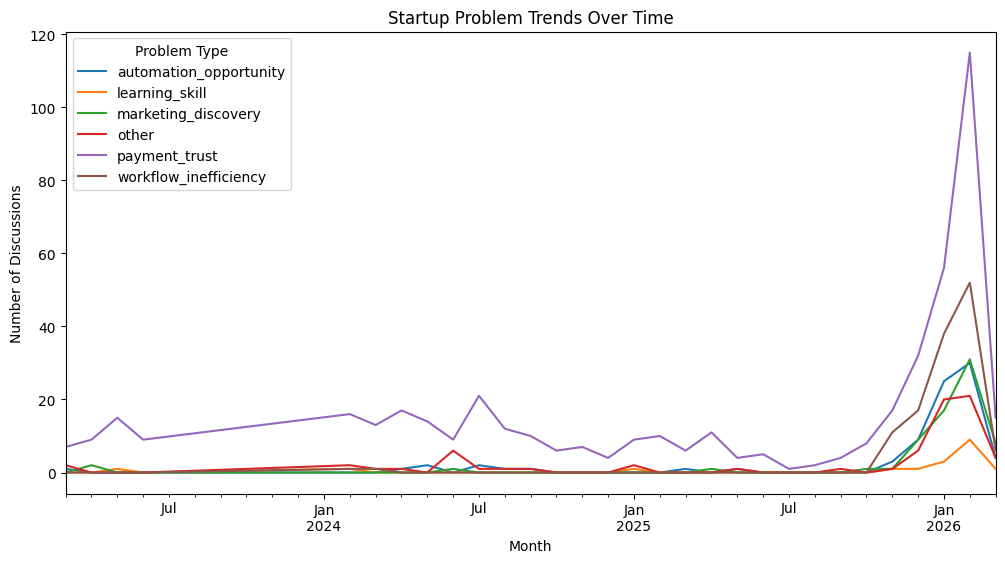

In [24]:
# ============================================
# VISUALIZE PROBLEM TRENDS
# ============================================

import matplotlib.pyplot as plt

trend_table.plot(figsize=(12,6))

plt.title("Startup Problem Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Discussions")

plt.legend(title="Problem Type")

plt.show()

In [26]:
# ============================================
# OPPORTUNITY SCORING — MARKET SIZE
# ============================================

market_size = filtered_df["problem_type"].value_counts()

print(market_size)

problem_type
payment_trust             464
workflow_inefficiency     126
automation_opportunity     81
marketing_discovery        71
other                      71
learning_skill             18
Name: count, dtype: int64


In [27]:
# ============================================
# OPPORTUNITY SCORING — ENGAGEMENT
# ============================================

engagement = filtered_df.groupby("problem_type")[["score","comments"]].mean()

print(engagement)

                             score   comments
problem_type                                 
automation_opportunity  547.765432  65.481481
learning_skill           92.333333  42.277778
marketing_discovery     124.718310  42.577465
other                   243.338028  76.464789
payment_trust            45.551724  40.653017
workflow_inefficiency    50.150794  26.142857


In [28]:
# ============================================
# FINAL OPPORTUNITY SCORING
# ============================================

# Market size
market_size = filtered_df["problem_type"].value_counts()

# Engagement
engagement = filtered_df.groupby("problem_type")[["score","comments"]].mean()

# Combine into single table
opportunity = pd.DataFrame({
    "market_size": market_size
})

opportunity = opportunity.join(engagement)

# Normalize metrics
opportunity["market_score"] = opportunity["market_size"] / opportunity["market_size"].max()

opportunity["engagement_score"] = (
    (opportunity["score"] + opportunity["comments"]) /
    (opportunity["score"] + opportunity["comments"]).max()
)

# Final score
opportunity["opportunity_score"] = (
    opportunity["market_score"] * 0.6 +
    opportunity["engagement_score"] * 0.4
)

# Rank opportunities
opportunity = opportunity.sort_values("opportunity_score", ascending=False)

print(opportunity)

                        market_size       score   comments  market_score  \
problem_type                                                               
payment_trust                   464   45.551724  40.653017      1.000000   
automation_opportunity           81  547.765432  65.481481      0.174569   
other                            71  243.338028  76.464789      0.153017   
workflow_inefficiency           126   50.150794  26.142857      0.271552   
marketing_discovery              71  124.718310  42.577465      0.153017   
learning_skill                   18   92.333333  42.277778      0.038793   

                        engagement_score  opportunity_score  
problem_type                                                 
payment_trust                   0.140571           0.656228  
automation_opportunity          1.000000           0.504741  
other                           0.521491           0.300407  
workflow_inefficiency           0.124409           0.212695  
marketing_discovery

In [29]:
# ============================================
# GENERATE STARTUP IDEAS
# ============================================

startup_ideas = {

"payment_trust": [
"Freelancer escrow payment platform",
"AI contract + invoice protection for freelancers",
"Client reputation system for gig workers"
],

"automation_opportunity":[
"AI automation marketplace for everyday tasks",
"Universal AI workflow assistant",
"No-code AI automation builder"
],

"workflow_inefficiency":[
"AI data analyst copilot",
"Automatic dashboard generator",
"AI-powered spreadsheet assistant"
],

"marketing_discovery":[
"AI customer discovery tool",
"Startup user acquisition assistant",
"AI marketing experiment generator"
]

}

for problem in opportunity.index[:3]:

    print("\n==============================")
    print("Opportunity:", problem)
    print("==============================")

    if problem in startup_ideas:

        for idea in startup_ideas[problem]:
            print("-", idea)


Opportunity: payment_trust
- Freelancer escrow payment platform
- AI contract + invoice protection for freelancers
- Client reputation system for gig workers

Opportunity: automation_opportunity
- AI automation marketplace for everyday tasks
- Universal AI workflow assistant
- No-code AI automation builder

Opportunity: other
